# Titanic Survival Classification

### Data Exploration

- Load the dataset using `pandas` into DataFrame
- See first 5 rows of dataset

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("../datasets/titanic.csv")
df.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


- Looking at the dataset we can get following insights:
    * `survived` and `alive` columns gives same information, so drop `alive` because its data type is object
    * also `pgclass` and `class` represents samething, so drop `class` column 
    * `sibsp` means number of `Siblings & Spouces` of that person
    * `parch` means number of `Parents & Children` of that person
    * `sibsp`+`parch` gives info about number relatives onboard
    * if person is `alone`, that means relatives onboard are also 0
    * `deck` column apperantly contains many null values
    * `embarked` & `embark_town` are same, first just the first letter of cities shown in second

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  889 non-null    str    
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 92.4 KB


- Yeah, titanic dataset is not that big, only 891 records total
- `age` contains null values
- `deck` means which floor of ship and it is mostly unknown/null

In [4]:
df.select_dtypes(include=["object"]).nunique()

/var/folders/zw/s4120bc94vdcwd8bd80yw_j80000gn/T/ipykernel_24773/3900290564.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include=["object"]).nunique()


sex            2
embarked       3
class          3
who            3
deck           7
embark_town    3
alive          2
dtype: int64

- we decided not to use duplicated columns, such as `class`, `embark_town`, `alive`
- lets see what categories needy ones have

In [5]:
for col in ['who', 'deck', 'embarked']:
    if df[col].dtype !='float64':
        print(f"{col}: {df[col].dtype}, {df[col].value_counts()}")
        print("-"*40)

who: str, who
man      537
woman    271
child     83
Name: count, dtype: int64
----------------------------------------
deck: str, deck
C    59
B    47
D    33
E    32
A    15
F    13
G     4
Name: count, dtype: int64
----------------------------------------
embarked: str, embarked
S    644
C    168
Q     77
Name: count, dtype: int64
----------------------------------------


- now is clear that `who` can be man, women or child 
- `age` column had some null values, later we can fill them using mean of groups of `who`s

array([[<Axes: title={'center': 'survived'}>,
        <Axes: title={'center': 'pclass'}>],
       [<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'sibsp'}>],
       [<Axes: title={'center': 'parch'}>,
        <Axes: title={'center': 'fare'}>]], dtype=object)

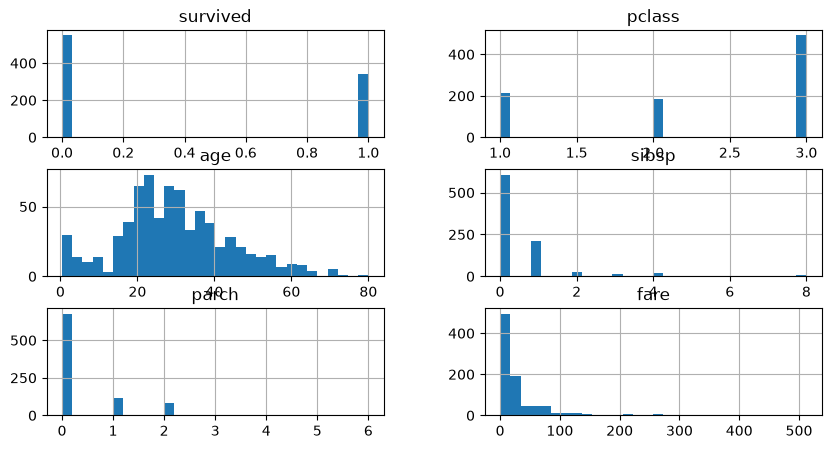

In [6]:
df.select_dtypes(include=["number"]).hist(bins=30, figsize=(10, 5))

- From this histogram, it is seen that `parch`, `sibsp` and `fare` columns are not equally distributed but they are right-skewed
- So I am going to perform logarithmic transformation in preprocessing stage

## Data Split

In [7]:
from sklearn.model_selection import train_test_split
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    df.drop(columns=["survived", "embark_town", "class", "alive"]), 
    df["survived"], test_size=0.2, random_state=42)

- we have splitted dataset into train and test sets in 8:2 ratio
- dropped target, and duplicated columns as well

## Data PreProcessing

In [8]:
df["age"] = df["age"].fillna(
    df.groupby("who")["age"].transform("median")
)
df['deck'] = df['deck'].fillna('Unknown')

- Filled missing agea with median of age groups which are `male`, `female`, `child`
- Filled missing deck floor numbers with the category name - `Unkown`

In [9]:
df["age"].isnull().sum(), df["deck"].isnull().sum()

(np.int64(0), np.int64(0))

- we have filled the age columns with median of suitable group
- also we have filled `deck` with just Unknown category

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer, KBinsDiscretizer, OneHotEncoder, StandardScaler

cat_features = ["sex", "pclass", "who", "deck", "embarked"]
num_features = [ "age", "sibsp", "parch", "fare"]

cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder()
)

log_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    FunctionTransformer(
        np.log1p,
        validate=False,
        feature_names_out="one-to-one"
    ),
    StandardScaler()
)

age_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    KBinsDiscretizer(
        n_bins=10,
        encode="onehot-dense",   # or ""
        strategy="kmeans"       # or "uniform", "kmeans"
    )
)


preprocessor = ColumnTransformer([
    ("cat", cat_pipeline, cat_features),
    ("num", log_pipeline, num_features),
    ("age_group", age_pipeline, ["age"])
], remainder="drop")

- First of all, we determined the numerical and cateogrical features
- `cat_pipeline` is an pipeline to transform categorical features into one-hot encoded binary features 
- `log_pipeline` is an pipeline to transform numerical and right-skewed features
- `age_pipeline` is an pipeline to make different age categories fetaure using `KBinsDicretizer` which bins continuous data into interval 
- Lastly, combined all pipelines into one using `ColumnTransformer`, and set `remainder`=`drop` which drops rest of all untransformed features in the output from preprocessing

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf_clf = make_pipeline(
    preprocessor,
    RandomForestClassifier( n_estimators=100, max_depth=5, random_state=42)
)

rf_clf

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columntransformer', ...), ('randomforestclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshol

In [12]:

grid_rf_params = {
    "randomforestclassifier__n_estimators": [100, 200, 300],
    "randomforestclassifier__max_depth": [3, 5, 7],
    "randomforestclassifier__min_samples_split": [2, 5, 10],
    "randomforestclassifier__min_samples_leaf": [1, 2, 4]
}

rf_grid = GridSearchCV(rf_clf, grid_rf_params, cv=5, scoring="accuracy")
rf_grid.fit(X_train_m, y_train_m)

print(f"Best Random Forest Classifier Parameters: {rf_grid.best_params_}")
print(f"Best Random Forest Classifier Accuracy: {rf_grid.best_score_:.4f}")


Best Random Forest Classifier Parameters: {'randomforestclassifier__max_depth': 7, 'randomforestclassifier__min_samples_leaf': 1, 'randomforestclassifier__min_samples_split': 2, 'randomforestclassifier__n_estimators': 100}
Best Random Forest Classifier Accuracy: 0.8371


- I tried `RandomForestClassifier` tree-based ensemble model
- connected preprocessing pipeline and model training stages using again `make_pipeline` function 
- fine-tuned model using `GridSearchCV` which tried total of 3^4 combinations of different hypermaraters
- used 5 fold cross-validation and scored accuracies of each validation and got best results among them

In [166]:
feature_names = rf_clf.named_steps['columntransformer'].get_feature_names_out()
feature_names

array(['cat__sex_female', 'cat__sex_male', 'cat__pclass_1',
       'cat__pclass_2', 'cat__pclass_3', 'cat__who_child', 'cat__who_man',
       'cat__who_woman', 'cat__deck_A', 'cat__deck_B', 'cat__deck_C',
       'cat__deck_D', 'cat__deck_E', 'cat__deck_F', 'cat__deck_G',
       'cat__embarked_C', 'cat__embarked_Q', 'cat__embarked_S',
       'num__age', 'num__sibsp', 'num__parch', 'num__fare',
       'age_group__age_0.0', 'age_group__age_1.0', 'age_group__age_2.0',
       'age_group__age_3.0', 'age_group__age_4.0', 'age_group__age_5.0',
       'age_group__age_6.0', 'age_group__age_7.0', 'age_group__age_8.0',
       'age_group__age_9.0'], dtype=object)

In [30]:
from sklearn.neighbors import KNeighborsClassifier

knn_clf = make_pipeline(
    preprocessor,
    KNeighborsClassifier(n_neighbors=5)
)


knn_grid_params = {
    "kneighborsclassifier__n_neighbors": [3, 5, 7, 9],
    "kneighborsclassifier__weights": ["uniform", "distance"],
    "kneighborsclassifier__metric": ["euclidean", "manhattan", "minkowski"],
}

knn_grid = GridSearchCV(knn_clf, knn_grid_params, cv=5, scoring="accuracy", n_jobs=-1)
knn_grid.fit(X_train_m, y_train_m)

print(f"Best K-Nearest Neighbors Classifier Parameters: {knn_grid.best_params_}")
print(f"Best K-Nearest Neighbors Classifier Accuracy: {knn_grid.best_score_:.4f}")

Best K-Nearest Neighbors Classifier Parameters: {'kneighborsclassifier__metric': 'manhattan', 'kneighborsclassifier__n_neighbors': 9, 'kneighborsclassifier__weights': 'uniform'}
Best K-Nearest Neighbors Classifier Accuracy: 0.8314


In [23]:
from sklearn.metrics import classification_report

y_pred_m = rf_grid.best_estimator_.predict(X_test_m)

print("RandomForest Classifier Results:")
print(classification_report(y_test_m, y_pred_m))

y_pred_m = knn_grid.best_estimator_.predict(X_test_m)

print("K-Nearest Neighbors Classifier Results:")
print(classification_report(y_test_m, y_pred_m))

RandomForest Classifier Results:
              precision    recall  f1-score   support

           0       0.81      0.88      0.84       105
           1       0.80      0.70      0.75        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179

K-Nearest Neighbors Classifier Results:
              precision    recall  f1-score   support

           0       0.81      0.90      0.85       105
           1       0.83      0.70      0.76        74

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.80       179
weighted avg       0.82      0.82      0.81       179



- yeah, `KNNClassifer` won with 82% accuracy on test, not only that but other metrics showed K-Nearest Neighbors Classifer better

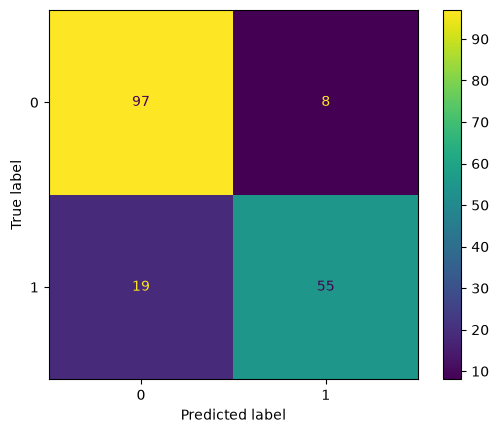

In [102]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test_m, y_pred_m)
plt.show()